In [1]:
import torch
from sentence_transformers import SentenceTransformer
print(torch.__version__)

c:\Users\bubashir\trademark-similarity-engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.5.1+cpu


In [2]:
!pip install tensorflow>=2.20.0 scikit-learn>=1.3.2 numpy>=1.24.3 pandas>=2.1.4 sentence-transformers>=2.2.2 jellyfish>=1.0.3 deep-translator>=1.11.4 matplotlib>=3.8.2 seaborn>=0.13.0 fastapi>=0.104.1 "uvicorn[standard]>=0.24.0" pydantic>=2.5.2 python-dotenv>=1.0.0 chardet>=5.2.0

In [ ]:
# STEP 1: COMPLETE DATA PREPROCESSING & FEATURE ENGINEERING
# =============================================================================
# This notebook prepares trademark similarity data for CNN+SVM training
# Output: Single clean CSV with visual/phonetic/semantic features
# =============================================================================

from datetime import datetime
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Optional
import re
import logging
from dataclasses import dataclass
from deep_translator import GoogleTranslator
from deep_translator.exceptions import TranslationNotFound
import chardet
import os
import warnings
import jellyfish
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10

# Enable tqdm for pandas
tqdm.pandas()

# =============================================================================
# CONFIGURATION
# =============================================================================

TRADEMARK_LEXICON = {
    # Business & Commerce
    "company": {"ha": "kamfani", "yo": "ilé-iṣẹ́"},
    "business": {"ha": "kasuwanci", "yo": "iṣẹ́ owó"},
    "market": {"ha": "kasuwa", "yo": "ọjà"},
    "store": {"ha": "shago", "yo": "ṣọ́ọ̀bù"},
    "brand": {"ha": "alama", "yo": "àmì"},
    
    # Quality
    "premium": {"ha": "mai kyau", "yo": "iyebíye"},
    "super": {"ha": "babba", "yo": "púpọ̀"},
    "best": {"ha": "mafi kyau", "yo": "dára jùlọ"},
    "gold": {"ha": "zinariya", "yo": "wúrà"},
    "silver": {"ha": "azurfa", "yo": "fàdákà"},
    
    # Food & Beverage
    "coffee": {"ha": "kofi", "yo": "kọ́fí"},
    "tea": {"ha": "shayi", "yo": "tii"},
    "food": {"ha": "abinci", "yo": "oúnjẹ"},
    "restaurant": {"ha": "gidan cin abinci", "yo": "ilé oúnjẹ"},
    
    # Technology
    "tech": {"ha": "fasaha", "yo": "ìmọ̀-ẹrọ"},
    "digital": {"ha": "na dijital", "yo": "oníjìtù"},
    "smart": {"ha": "mai hankali", "yo": "ológbọ́n"},
    "online": {"ha": "kan layi", "yo": "lórí ayélujára"},
    
    # Common terms
    "new": {"ha": "sabon", "yo": "títun"},
    "fresh": {"ha": "sabo", "yo": "tuntun"},
    "natural": {"ha": "na halitta", "yo": "àdáyébá"},
}

def get_incremented_filename(base_name: str) -> str:
    """
    Returns a filename that doesn't exist yet by appending _1, _2, etc.
    Example: 'data.csv' → 'data_1.csv' if 'data.csv' exists.
    """
    if not os.path.exists(base_name):
        return base_name

    name, ext = os.path.splitext(base_name)
    counter = 1
    while True:
        new_name = f"{name}_{counter}{ext}"
        if not os.path.exists(new_name):
            return new_name
        counter += 1

@dataclass
class PreprocessingConfig:
    """Configuration for the entire pipeline"""
    # Data sampling
    max_rows: Optional[int] = None  # None = process all rows
    sampling_strategy: str = 'first'  # 'first', 'random', or 'all'
    
    # Translation
    translate_to_english: bool = True
    translate_to_local: bool = True
    
    # Cleaning
    fix_encoding: bool = True
    remove_duplicates: bool = True
    handle_missing: str = 'drop'
    
    # Negative pair generation
    negative_ratio: float = 1.0
    negative_strategy: str = 'mixed'
    
    # Output
    output_filename: str = 'trademark_similarity_dataset_final.csv'
    save_visualizations: bool = True

# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def validate_wordmark(text: str) -> bool:
    """Check if a wordmark is valid (not empty/null)"""
    if pd.isna(text):
        return False
    text = str(text).strip()
    return len(text) > 0 and text.lower() not in ['nan', 'none', 'null', '']

def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Remove all rows with invalid wordmarks"""
    initial_len = len(df)
    
    # Remove rows with missing/invalid wordmarks
    if 'mark1_wordmark' in df.columns and 'mark2_wordmark' in df.columns:
        df = df[
            df['mark1_wordmark'].apply(validate_wordmark) &
            df['mark2_wordmark'].apply(validate_wordmark)
        ].copy()
    
    removed = initial_len - len(df)
    if removed > 0:
        logger.info(f"🧹 Removed {removed} rows with invalid wordmarks")
    
    return df

# =============================================================================
# ENHANCED TRANSLATOR
# =============================================================================

class EnhancedTranslator:
    """Multi-strategy translator: Lexicon → HuggingFace → Google Translate"""
    
    def __init__(self):
        self.lexicon = TRADEMARK_LEXICON
        self.google_translators = {
            'ha': GoogleTranslator(source='en', target='ha'),
            'yo': GoogleTranslator(source='en', target='yo')
        }
        self.cache = {}
        self.stats = {'lexicon': 0, 'google': 0, 'cache': 0, 'failed': 0}
    
    def translate_word(self, word: str, target_lang: str) -> str:
        """Translate a single word with error handling"""
        if not word or not word.strip():
            return ""
        
        word_lower = word.lower().strip()
        cache_key = f"{target_lang}:{word_lower}"
        
        # Check cache
        if cache_key in self.cache:
            self.stats['cache'] += 1
            return self.cache[cache_key]
        
        # Try lexicon
        if word_lower in self.lexicon:
            translation = self.lexicon[word_lower].get(target_lang, word)
            self.stats['lexicon'] += 1
            self.cache[cache_key] = translation
            return translation
        
        # Fallback to Google Translate with error handling
        try:
            translation = self.google_translators[target_lang].translate(word)
            self.stats['google'] += 1
            self.cache[cache_key] = translation
            return translation
        except (TranslationNotFound, Exception) as e:
            # If translation fails, return original word
            self.stats['failed'] += 1
            self.cache[cache_key] = word
            return word
    
    def translate_text(self, text: str, target_lang: str) -> str:
        """Translate full text"""
        if pd.isna(text) or not str(text).strip():
            return ""
        
        words = re.findall(r"\b\w+\b", str(text))
        translated = [self.translate_word(w, target_lang) for w in words]
        return " ".join(translated)

# =============================================================================
# FEATURE EXTRACTOR (FIXED PHONETIC FEATURES)
# =============================================================================

class FeatureExtractor:
    """Extract visual, phonetic, and semantic features"""
    
    def __init__(self):
        self.semantic_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    
    def extract_visual_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Extract character-level visual similarity features"""
        logger.info("🔍 Extracting visual features...")
        
        df['visual_levenshtein'] = df.apply(
            lambda row: jellyfish.levenshtein_distance(
                str(row['mark1_wordmark']), 
                str(row['mark2_wordmark'])
            ), axis=1
        )
        
        df['visual_jaro_winkler'] = df.apply(
            lambda row: jellyfish.jaro_winkler_similarity(
                str(row['mark1_wordmark']), 
                str(row['mark2_wordmark'])
            ), axis=1
        )
        
        return df
    
    def extract_phonetic_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Extract phonetic similarity features
        FIXED: Now uses English translations for better phonetic matching
        """
        logger.info("👂 Extracting phonetic features...")
        
        # Use English translations for phonetic comparison
        def safe_soundex(text):
            try:
                if pd.isna(text) or not str(text).strip():
                    return ""
                return jellyfish.soundex(str(text))
            except:
                return ""
        
        def safe_metaphone(text):
            try:
                if pd.isna(text) or not str(text).strip():
                    return ""
                return jellyfish.metaphone(str(text))
            except:
                return ""
        
        # Soundex comparison on English wordmarks
        df['soundex_match'] = df.apply(
            lambda row: int(
                safe_soundex(row.get('mark1_wordmark_en', '')) == 
                safe_soundex(row.get('mark2_wordmark_en', ''))
                and safe_soundex(row.get('mark1_wordmark_en', '')) != ""
            ), axis=1
        )
        
        # Metaphone comparison on English wordmarks
        df['metaphone_match'] = df.apply(
            lambda row: int(
                safe_metaphone(row.get('mark1_wordmark_en', '')) == 
                safe_metaphone(row.get('mark2_wordmark_en', ''))
                and safe_metaphone(row.get('mark1_wordmark_en', '')) != ""
            ), axis=1
        )
        
        return df
    
    def _safe_encode(self, texts: List[str]) -> np.ndarray:
        """Safely encode texts handling NaN/empty values"""
        clean_texts = [str(t) if pd.notna(t) and str(t).strip() else "" for t in texts]
        return self.semantic_model.encode(clean_texts, show_progress_bar=False)
    
    def extract_semantic_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Extract semantic similarity features for all languages"""
        logger.info("🧠 Extracting semantic features...")
        
        for lang in ['en', 'ha', 'yo']:
            col1 = f'mark1_wordmark_{lang}'
            col2 = f'mark2_wordmark_{lang}'
            
            if col1 in df.columns and col2 in df.columns:
                emb1 = self._safe_encode(df[col1].tolist())
                emb2 = self._safe_encode(df[col2].tolist())
                
                df[f'semantic_similarity_{lang}'] = [
                    float(cosine_similarity([e1], [e2])[0][0])
                    for e1, e2 in zip(emb1, emb2)
                ]
        
        return df
    
    def extract_all(self, df: pd.DataFrame) -> pd.DataFrame:
        """Extract all features"""
        df = self.extract_visual_features(df)
        df = self.extract_phonetic_features(df)
        df = self.extract_semantic_features(df)
        return df

# =============================================================================
# MAIN PREPROCESSOR
# =============================================================================

class TrademarkPreprocessor:
    """Complete preprocessing pipeline"""
    
    def __init__(self, config: PreprocessingConfig = None):
        self.config = config or PreprocessingConfig()
        self.translator = EnhancedTranslator()
        self.feature_extractor = FeatureExtractor()
        self.pt_to_en = GoogleTranslator(source='pt', target='en')
        self.cache = {}
    
    def load_data(self, file_path: str) -> pd.DataFrame:
        """Load CSV with encoding detection"""
        logger.info("📂 Loading dataset...")
        
        # Detect encoding
        with open(file_path, 'rb') as f:
            result = chardet.detect(f.read(100000))
        encoding = result['encoding']
        
        # Try multiple encodings
        for enc in [encoding, 'MacRoman', 'utf-8', 'latin-1']:
            try:
                df = pd.read_csv(file_path, encoding=enc)
                logger.info(f"✓ Loaded with encoding: {enc}")
                logger.info(f"   Shape: {df.shape}")
                return df
            except Exception:
                continue
        
        raise ValueError("Could not load CSV with any encoding")
    
    def extract_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """Extract and rename relevant columns (excluding class info)"""
        logger.info("📋 Extracting relevant columns...")
        
        column_mapping = {
            'Process number RM': 'mark1_id',
            'Process number TM': 'mark2_id',
            'Name RM': 'mark1_wordmark',
            'Name TM': 'mark2_wordmark',
            'Status RM': 'mark1_status',
            'Status TM': 'mark2_status',
        }
        
        available = [c for c in column_mapping.keys() if c in df.columns]
        df_proc = df[available].copy()
        df_proc.rename(columns=column_mapping, inplace=True)
        df_proc['label'] = 1  # All are similar pairs
        
        return df_proc
    
    def clean_text(self, text: str) -> str:
        """Clean text"""
        if pd.isna(text) or not str(text).strip():
            return ""
        
        text = str(text)
        
        # Fix encoding issues
        fixes = {
            'v�': 'ç', 'v�o': 'ção', 'v�': 'í', 'v=': 'ó', '?': ''
        }
        for bad, good in fixes.items():
            text = text.replace(bad, good)
        
        return ' '.join(text.split()).strip()
    
    def safe_translate(self, text: str) -> str:
        """Safely translate text from Portuguese to English with error handling"""
        if not text or pd.isna(text):
            return ""
        try:
            return self.pt_to_en.translate(text)
        except (TranslationNotFound, Exception) as e:
            # If translation fails, return original text
            logger.debug(f"Translation failed for '{text}': {e}")
            return text
    
    def translate_dataset(self, df: pd.DataFrame) -> pd.DataFrame:
        """Translate wordmarks to English, Hausa, Yoruba"""
        logger.info("🌍 Translating dataset...")
        
        for col in ['mark1_wordmark', 'mark2_wordmark']:
            if col not in df.columns:
                continue
            
            # Clean first
            logger.info(f"   ➤ Cleaning {col}...")
            df[col] = df[col].progress_apply(self.clean_text)
            
            # Portuguese → English with error handling
            en_col = col.replace('_wordmark', '_wordmark_en')
            logger.info(f"   ➤ Translating {col} to English...")
            df[en_col] = df[col].progress_apply(self.safe_translate)
            
            # English → Hausa & Yoruba
            for lang in ['ha', 'yo']:
                lang_col = col.replace('_wordmark', f'_wordmark_{lang}')
                lang_name = 'Hausa' if lang == 'ha' else 'Yoruba'
                logger.info(f"   ➤ Translating {col} to {lang_name}...")
                df[lang_col] = df[en_col].progress_apply(
                    lambda x: self.translator.translate_text(x, lang)
                )
        
        # Show translation stats
        stats = self.translator.stats
        total = sum(stats.values())
        if total > 0:
            logger.info(f"\n📊 Translation Statistics:")
            logger.info(f"   Lexicon: {stats['lexicon']} ({stats['lexicon']/total*100:.1f}%)")
            logger.info(f"   Google: {stats['google']} ({stats['google']/total*100:.1f}%)")
            logger.info(f"   Cache hits: {stats['cache']} ({stats['cache']/total*100:.1f}%)")
            if stats['failed'] > 0:
                logger.info(f"   Failed: {stats['failed']} ({stats['failed']/total*100:.1f}%)")
        
        return df
    
    def generate_negative_pairs(self, df: pd.DataFrame) -> pd.DataFrame:
        """Generate dissimilar pairs (without class filtering)"""
        logger.info(f"🔄 Generating negative pairs (ratio: {self.config.negative_ratio})...")
        
        # Get valid wordmarks
        all_marks = list(set(
            df['mark1_wordmark'].tolist() + df['mark2_wordmark'].tolist()
        ))
        all_marks = [m for m in all_marks if validate_wordmark(m)]
        
        if len(all_marks) < 2:
            logger.warning("⚠ Not enough wordmarks for negative pairs")
            return pd.DataFrame()
        
        # Track existing pairs
        existing = set()
        for _, row in df.iterrows():
            pair = tuple(sorted([
                str(row['mark1_wordmark']),
                str(row['mark2_wordmark'])
            ]))
            existing.add(pair)
        
        # Generate negatives
        n_negative = int(len(df) * self.config.negative_ratio)
        negatives = []
        attempts = 0
        max_attempts = n_negative * 100
        
        with tqdm(total=n_negative, desc="Generating negative pairs") as pbar:
            while len(negatives) < n_negative and attempts < max_attempts:
                attempts += 1
                
                mark1 = np.random.choice(all_marks)
                mark2 = np.random.choice(all_marks)
                
                # Validate
                if mark1 == mark2:
                    continue
                
                pair = tuple(sorted([mark1, mark2]))
                if pair in existing:
                    continue
                
                # Length difference check for dissimilarity
                if self.config.negative_strategy == 'mixed':
                    len_diff = abs(len(mark1) - len(mark2))
                    if len_diff < 3:  # Must have some length difference
                        continue
                
                existing.add(pair)
                negatives.append({
                    'mark1_wordmark': mark1,
                    'mark2_wordmark': mark2,
                    'label': 0,
                    'pair_type': 'negative'
                })
                pbar.update(1)
        
        logger.info(f"✓ Generated {len(negatives)} negative pairs")
        return pd.DataFrame(negatives)
    
    def add_basic_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add basic statistical features"""
        df['mark1_length'] = df['mark1_wordmark'].str.len()
        df['mark2_length'] = df['mark2_wordmark'].str.len()
        df['length_diff'] = abs(df['mark1_length'] - df['mark2_length'])
        return df
    
    def process(self, file_path: str) -> pd.DataFrame:
        """Complete pipeline"""
        logger.info("=" * 80)
        logger.info("STEP 1: TRADEMARK SIMILARITY DATA PREPROCESSING")
        logger.info("=" * 80)
        
        # 1. Load
        df = self.load_data(file_path)
        
        # 2. Extract columns (no class info)
        df = self.extract_columns(df)
        
        # 3. Sample (if configured)
        if self.config.max_rows and self.config.sampling_strategy != 'all':
            n = min(self.config.max_rows, len(df))
            if self.config.sampling_strategy == 'first':
                df = df.head(n).copy()
            elif self.config.sampling_strategy == 'random':
                df = df.sample(n=n, random_state=42).copy()
            logger.info(f"📝 Sampled {n} rows ({self.config.sampling_strategy})")
        
        # 4. Clean
        df = clean_dataframe(df)
        
        # 5. Remove duplicates
        initial = len(df)
        df['_pair_key'] = df.apply(
            lambda r: tuple(sorted([
                str(r['mark1_wordmark']),
                str(r['mark2_wordmark'])
            ])), axis=1
        )
        df = df.drop_duplicates(subset='_pair_key').drop('_pair_key', axis=1)
        logger.info(f"🗑️  Removed {initial - len(df)} duplicates")
        
        # 6. Translate
        df['pair_type'] = 'positive'
        df = self.translate_dataset(df)
        
        # 7. Generate negatives
        negative_df = self.generate_negative_pairs(df)
        
        if len(negative_df) > 0:
            # Translate negatives
            logger.info("🌍 Translating negative pairs...")
            for col in ['mark1_wordmark', 'mark2_wordmark']:
                en_col = col.replace('_wordmark', '_wordmark_en')
                logger.info(f"   ➤ Translating {col} to English...")
                negative_df[en_col] = negative_df[col].progress_apply(self.safe_translate)
                
                for lang in ['ha', 'yo']:
                    lang_col = col.replace('_wordmark', f'_wordmark_{lang}')
                    lang_name = 'Hausa' if lang == 'ha' else 'Yoruba'
                    logger.info(f"   ➤ Translating {col} to {lang_name}...")
                    negative_df[lang_col] = negative_df[en_col].progress_apply(
                        lambda x: self.translator.translate_text(x, lang)
                    )
            
            # Combine
            df = pd.concat([df, negative_df], ignore_index=True)
            df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        
        # 8. Add features
        df = self.add_basic_features(df)
        df = self.feature_extractor.extract_all(df)
        
        # 9. Final cleaning
        df = clean_dataframe(df)
        
        logger.info("=" * 80)
        logger.info("✅ PREPROCESSING COMPLETE")
        logger.info(f"   Total pairs: {len(df)}")
        logger.info(f"   Positive: {(df['label']==1).sum()}")
        logger.info(f"   Negative: {(df['label']==0).sum()}")
        logger.info(f"   Features: {len(df.columns)}")
        logger.info("=" * 80)
        
        return df

# =============================================================================
# EXPLORATORY DATA ANALYSIS (SEPARATE VISUALIZATIONS)
# =============================================================================

class TrademarkEDA:
    """Comprehensive EDA with separate, readable visualizations"""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
    
    def create_visualizations(self, output_dir: str = '.'):
        """Create separate visualization files for better readability"""
        os.makedirs(output_dir, exist_ok=True)
        
        # 1. Label Distribution
        self._plot_label_distribution(output_dir)
        
        # 2. Wordmark Length Distribution
        self._plot_length_distribution(output_dir)
        
        # 3. Visual Similarity Distribution
        self._plot_visual_similarity(output_dir)
        
        # 4. Phonetic Match Distribution
        self._plot_phonetic_matches(output_dir)
        
        # 5. Semantic Similarity by Language
        self._plot_semantic_similarity(output_dir)
        
        # 6. Feature Correlation Heatmap
        self._plot_correlation_heatmap(output_dir)
        
        # 7. Length Difference by Label
        self._plot_length_difference(output_dir)
        
        logger.info(f"📊 All visualizations saved to: {output_dir}/")
    
    def _plot_label_distribution(self, output_dir):
        fig, ax = plt.subplots(figsize=(8, 8))
        label_counts = self.df['label'].value_counts()
        colors = ['#2ecc71', '#e74c3c']
        ax.pie(label_counts.values, labels=['Similar', 'Dissimilar'], 
               autopct='%1.1f%%', startangle=90, colors=colors,
               textprops={'fontsize': 14, 'weight': 'bold'})
        ax.set_title('Label Distribution', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'{output_dir}/01_label_distribution.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    def _plot_length_distribution(self, output_dir):
        fig, ax = plt.subplots(figsize=(12, 6))
        all_lengths = pd.concat([self.df['mark1_length'], self.df['mark2_length']])
        ax.hist(all_lengths, bins=30, color='coral', edgecolor='black', alpha=0.7)
        ax.axvline(all_lengths.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {all_lengths.mean():.1f}')
        ax.set_xlabel('Wordmark Length (characters)', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title('Wordmark Length Distribution', fontsize=16, fontweight='bold', pad=20)
        ax.legend(fontsize=12)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{output_dir}/02_length_distribution.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    def _plot_visual_similarity(self, output_dir):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Levenshtein
        for label in [0, 1]:
            subset = self.df[self.df['label'] == label]['visual_levenshtein']
            ax1.hist(subset, bins=20, alpha=0.6, 
                    label=f'{"Similar" if label==1 else "Dissimilar"}')
        ax1.set_xlabel('Levenshtein Distance', fontsize=12)
        ax1.set_ylabel('Frequency', fontsize=12)
        ax1.set_title('Visual Similarity: Levenshtein Distance', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(alpha=0.3)
        
        # Jaro-Winkler
        for label in [0, 1]:
            subset = self.df[self.df['label'] == label]['visual_jaro_winkler']
            ax2.hist(subset, bins=20, alpha=0.6, 
                    label=f'{"Similar" if label==1 else "Dissimilar"}')
        ax2.set_xlabel('Jaro-Winkler Similarity', fontsize=12)
        ax2.set_ylabel('Frequency', fontsize=12)
        ax2.set_title('Visual Similarity: Jaro-Winkler', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/03_visual_similarity.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    def _plot_phonetic_matches(self, output_dir):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Soundex
        soundex_counts = self.df.groupby(['label', 'soundex_match']).size().unstack(fill_value=0)
        soundex_counts.plot(kind='bar', ax=ax1, color=['#e74c3c', '#2ecc71'])
        ax1.set_xlabel('Label', fontsize=12)
        ax1.set_ylabel('Count', fontsize=12)
        ax1.set_title('Phonetic Match: Soundex', fontsize=14, fontweight='bold')
        ax1.set_xticklabels(['Dissimilar', 'Similar'], rotation=0)
        ax1.legend(['No Match', 'Match'], fontsize=11)
        ax1.grid(alpha=0.3)
        
        # Metaphone
        metaphone_counts = self.df.groupby(['label', 'metaphone_match']).size().unstack(fill_value=0)
        metaphone_counts.plot(kind='bar', ax=ax2, color=['#e74c3c', '#2ecc71'])
        ax2.set_xlabel('Label', fontsize=12)
        ax2.set_ylabel('Count', fontsize=12)
        ax2.set_title('Phonetic Match: Metaphone', fontsize=14, fontweight='bold')
        ax2.set_xticklabels(['Dissimilar', 'Similar'], rotation=0)
        ax2.legend(['No Match', 'Match'], fontsize=11)
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/04_phonetic_matches.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    def _plot_semantic_similarity(self, output_dir):
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        langs = ['en', 'ha', 'yo']
        
        # Distributions by label for each language
        for idx, lang in enumerate(langs):
            row = idx // 2
            col = idx % 2
            ax = axes[row, col]
            
            for label in [0, 1]:
                subset = self.df[self.df['label'] == label][f'semantic_similarity_{lang}']
                ax.hist(subset, bins=20, alpha=0.6, 
                       label=f'{"Similar" if label==1 else "Dissimilar"}')
            
            lang_names = {'en': 'English', 'ha': 'Hausa', 'yo': 'Yoruba'}
            ax.set_xlabel('Cosine Similarity', fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.set_title(f'Semantic Similarity: {lang_names[lang]}', fontsize=14, fontweight='bold')
            ax.legend(fontsize=11)
            ax.grid(alpha=0.3)
        
        # Comparison bar chart
        ax = axes[1, 1]
        means = [self.df[f'semantic_similarity_{lang}'].mean() for lang in langs]
        colors = ['#3498db', '#e67e22', '#9b59b6']
        bars = ax.bar(['English', 'Hausa', 'Yoruba'], means, color=colors, alpha=0.7, edgecolor='black')
        ax.set_ylabel('Average Similarity', fontsize=12)
        ax.set_title('Semantic Similarity by Language', fontsize=14, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/05_semantic_similarity.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    def _plot_correlation_heatmap(self, output_dir):
        fig, ax = plt.subplots(figsize=(14, 12))
        
        feature_cols = [
            'visual_levenshtein', 'visual_jaro_winkler',
            'soundex_match', 'metaphone_match',
            'semantic_similarity_en', 'semantic_similarity_ha', 'semantic_similarity_yo',
            'length_diff', 'label'
        ]
        
        corr_data = self.df[feature_cols].corr()
        sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                   ax=ax, cbar_kws={'label': 'Correlation'}, 
                   square=True, linewidths=1)
        ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    def _plot_length_difference(self, output_dir):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        data_to_plot = [
            self.df[self.df['label'] == 0]['length_diff'],
            self.df[self.df['label'] == 1]['length_diff']
        ]
        
        bp = ax.boxplot(data_to_plot, labels=['Dissimilar', 'Similar'],
                       patch_artist=True, showmeans=True)
        
        colors = ['#e74c3c', '#2ecc71']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Label', fontsize=12)
        ax.set_ylabel('Length Difference', fontsize=12)
        ax.set_title('Length Difference by Label', fontsize=16, fontweight='bold', pad=20)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/07_length_difference.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    def print_statistics(self):
        """Print detailed statistics"""
        print("\n" + "=" * 80)
        print("DATASET STATISTICS")
        print("=" * 80)
        
        print(f"\n📊 Dataset Overview:")
        print(f"   Total pairs: {len(self.df):,}")
        print(f"   Similar pairs: {(self.df['label']==1).sum():,} ({(self.df['label']==1).mean()*100:.1f}%)")
        print(f"   Dissimilar pairs: {(self.df['label']==0).sum():,} ({(self.df['label']==0).mean()*100:.1f}%)")
        print(f"   Total features: {len(self.df.columns)}")
        
        print(f"\n📏 Wordmark Statistics:")
        print(f"   Average length: {self.df['mark1_length'].mean():.1f} characters")
        print(f"   Min length: {self.df['mark1_length'].min()}")
        print(f"   Max length: {self.df['mark1_length'].max()}")
        
        print(f"\n🎯 Feature Quality:")
        print(f"   Visual similarity (Jaro-Winkler): {self.df['visual_jaro_winkler'].mean():.3f}")
        print(f"   Phonetic match rate (Soundex): {self.df['soundex_match'].mean()*100:.1f}%")
        print(f"   Phonetic match rate (Metaphone): {self.df['metaphone_match'].mean()*100:.1f}%")
        print(f"   Semantic similarity (EN): {self.df['semantic_similarity_en'].mean():.3f}")
        print(f"   Semantic similarity (HA): {self.df['semantic_similarity_ha'].mean():.3f}")
        print(f"   Semantic similarity (YO): {self.df['semantic_similarity_yo'].mean():.3f}")
        
        print("\n" + "=" * 80)

# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    """Run complete pipeline"""
    
    # Configuration
    config = PreprocessingConfig(
        max_rows=None,  # Set to None to process all data
        sampling_strategy='first',
        negative_ratio=1.0,
        negative_strategy='mixed',
        output_filename='data/trademark_similarity_dataset_final.csv',
        save_visualizations=True
    )
    
    # Process
    preprocessor = TrademarkPreprocessor(config)
    df = preprocessor.process('data/trademark_file.csv')
    
    # EDA
    eda = TrademarkEDA(df)
    eda.print_statistics()
    
    if config.save_visualizations:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        viz_dir = f"eda_visualizations_{timestamp}"
        eda.create_visualizations(viz_dir)
    
    # Save final dataset
    # Generate a safe, non-overwriting filename
    safe_output_file = get_incremented_filename(config.output_filename)
    df.to_csv(safe_output_file, index=False, encoding='utf-8')
    logger.info(f"\n💾 Final dataset saved: {safe_output_file}")
    logger.info(f"   Shape: {df.shape}")
    logger.info(f"   File size: {os.path.getsize(safe_output_file) / 1024**2:.2f} MB")
    
    # Show sample
    print("\n" + "=" * 80)
    print("SAMPLE DATA (First 5 rows)")
    print("=" * 80)
    display_cols = [
        'mark1_wordmark', 'mark2_wordmark', 'label',
        'visual_levenshtein', 'soundex_match', 'metaphone_match', 'semantic_similarity_en'
    ]
    print(df[display_cols].head(5).to_string(index=False))
    
    print("\n✅ STEP 1 COMPLETE - Ready for Step 2 (CNN Architecture)")
    print(f"   Use file: {safe_output_file}")
    print(f"   Visualizations: {viz_dir} directory")

    with open('pipeline_config.json', 'w') as f:
        json.dump({
            'processed_data_file': safe_output_file,
            'timestamp': datetime.now().isoformat()
        }, f)
    
    return df

# Run pipeline
if __name__ == "__main__":
    final_df = main()


INFO: Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2
INFO: Use pytorch device_name: cpu
INFO: ================================================================================
INFO: STEP 1: TRADEMARK SIMILARITY DATA PREPROCESSING
INFO: ================================================================================
INFO: 📂 Loading dataset...
INFO: ✓ Loaded with encoding: MacRoman
INFO:    Shape: (18737, 18)
INFO: 📋 Extracting relevant columns...
INFO: 🧹 Removed 381 rows with invalid wordmarks
INFO: 🗑️  Removed 3553 duplicates
INFO: 🌍 Translating dataset...
INFO:    ➤ Cleaning mark1_wordmark...
100%|██████████| 14803/14803 [00:00<00:00, 821023.79it/s]
INFO:    ➤ Translating mark1_wordmark to English...
 52%|█████▏    | 7640/14803 [2:02:07<1:27:02,  1.37it/s] 

c:\Users\bubashir\trademark-similarity-engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


STEP 2 & 3: CNN-ONLY, SVM-ONLY & HYBRID COMPARISON
✅ Using dataset from Step 1: data/trademark_similarity_dataset_final_8.csv

COMPREHENSIVE MODEL TRAINING & COMPARISON

📂 Loading preprocessed data...
✓ Loaded 29606 trademark pairs
  Positive: 14803
  Negative: 14803
✓ Extracted 10 linguistic features

📊 Data Split:
   Train: 20724 (10362 positive)
   Val:   4441 (2221 positive)
   Test:  4441 (2220 positive)

MODEL 1: CNN-ONLY (Siamese Network)
✓ Built character tokenizer (vocab size: 98)

🔤 Encoding texts to sequences...


🏗️  CNN Architecture:
Model: "siamese_cnn"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 mark1 (InputLayer)          [(None, 50)]                 0         []                            
                                                                                                  
 mark2 (InputLayer)          [

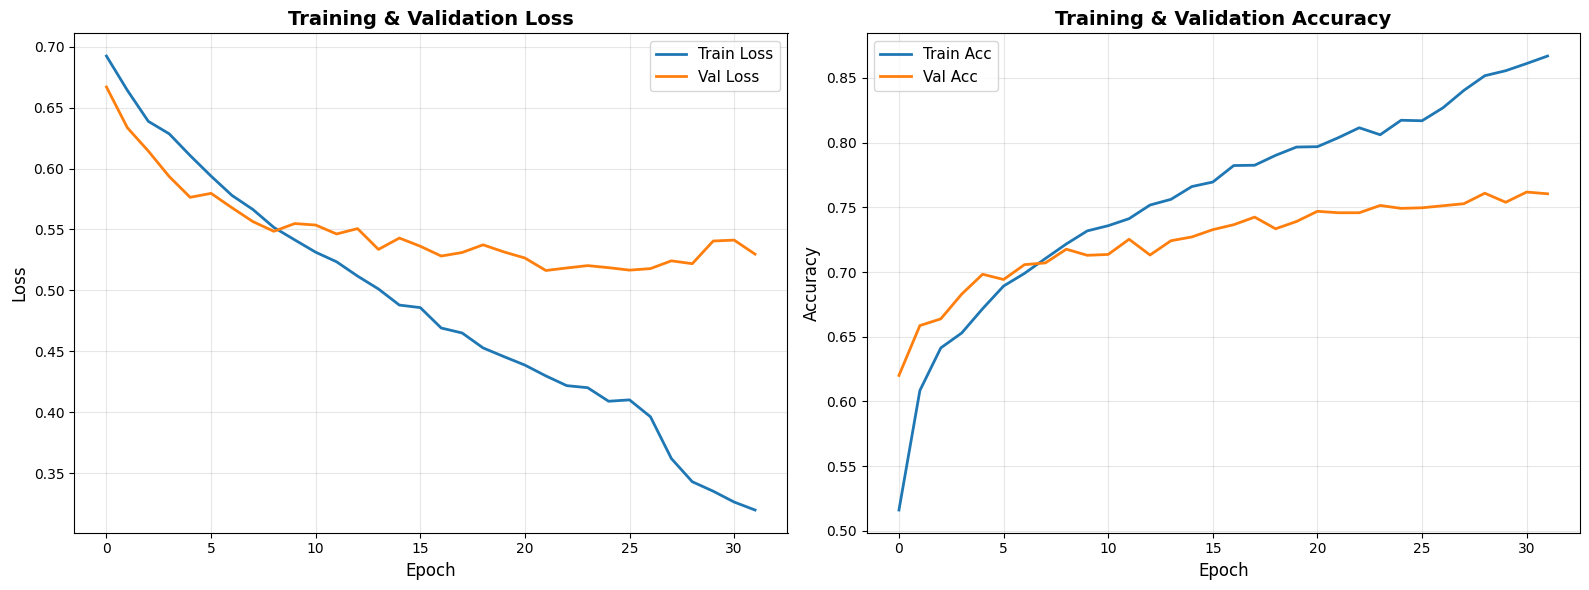


📊 Evaluating CNN-Only Model...

CNN-Only - Test Set Evaluation

📊 Primary Metrics:
   Accuracy:          0.7480
   Balanced Accuracy: 0.7480
   Precision:         0.7374
   Recall (TPR):      0.7703
   Specificity (TNR): 0.7258
   F1 Score:          0.7535

🎯 Advanced Metrics:
   ROC-AUC:           0.8273
   Avg Precision:     0.8191
   Matthews Corr:     0.4966
   Cohen's Kappa:     0.4961
   Log Loss:          0.5243

📈 Error Rates:
   False Positive Rate: 0.2742
   False Negative Rate: 0.2297

🔢 Confusion Matrix:
   True Positives:  1710
   True Negatives:  1612
   False Positives: 609
   False Negatives: 510

              precision    recall  f1-score   support

  Dissimilar       0.76      0.73      0.74      2221
     Similar       0.74      0.77      0.75      2220

    accuracy                           0.75      4441
   macro avg       0.75      0.75      0.75      4441
weighted avg       0.75      0.75      0.75      4441

✓ Saved CNN model to models\cnn_encoder.keras

MODE

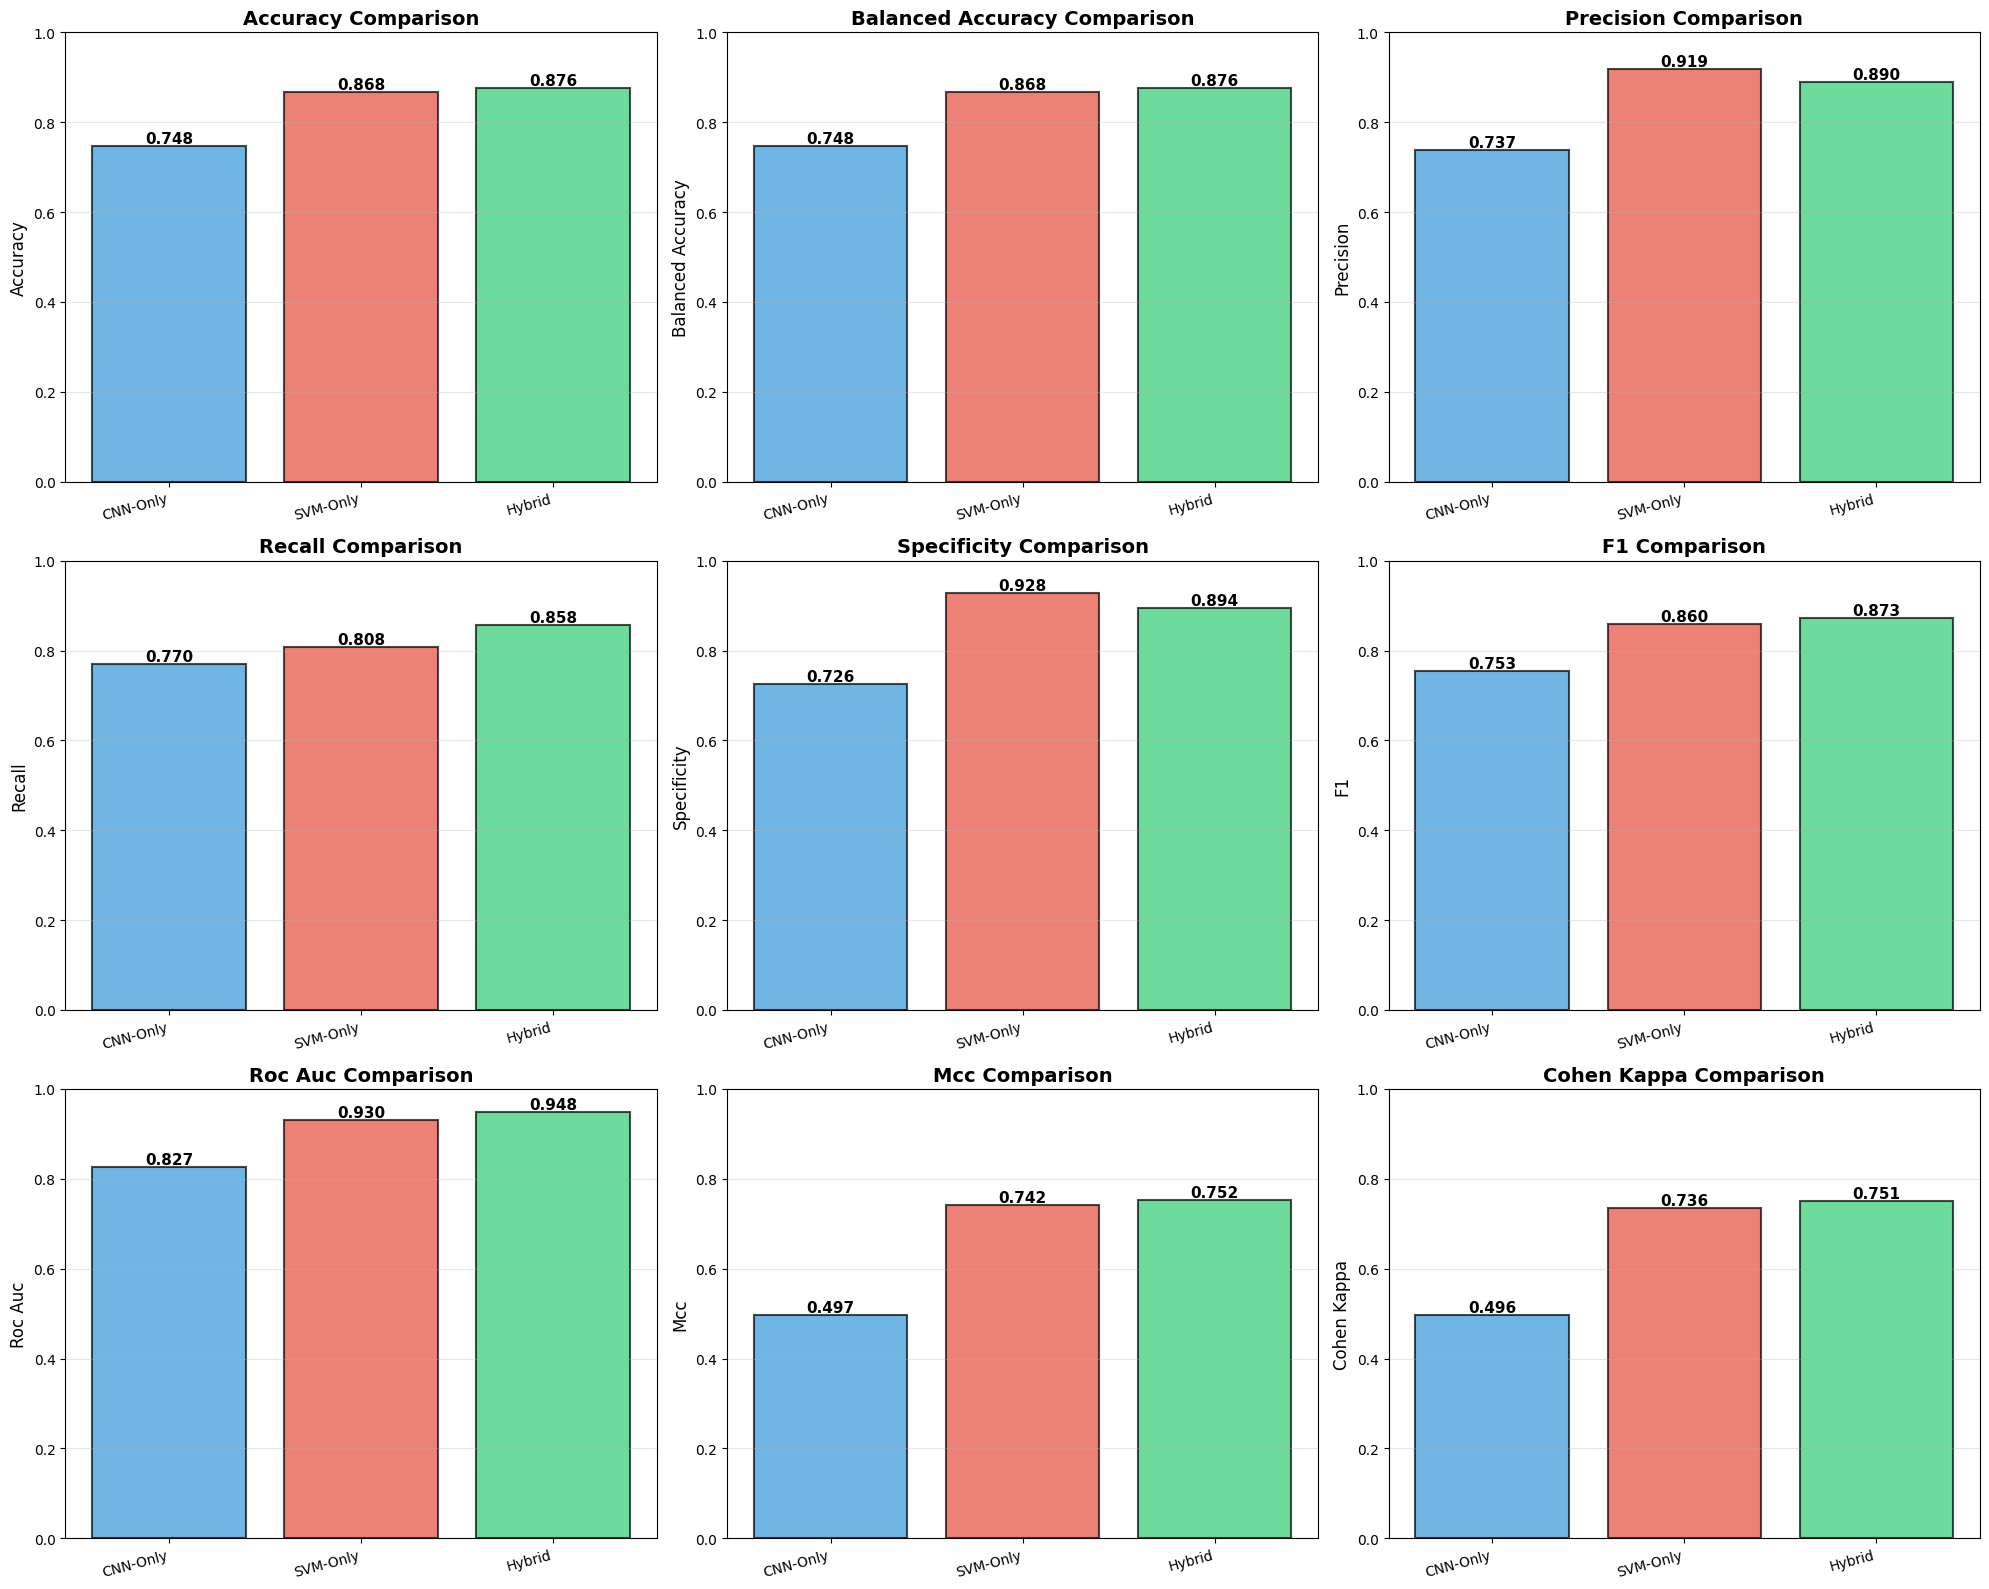


MODEL COMPARISON TABLE
          accuracy  balanced_accuracy  precision    recall  specificity        f1   roc_auc       mcc  cohen_kappa
CNN-Only  0.748030           0.748035   0.737387  0.770270     0.725799  0.753470  0.827337  0.496558     0.496064
SVM-Only  0.868048           0.868034   0.918545  0.807658     0.928411  0.859540  0.930056  0.741509     0.736088
Hybrid    0.875704           0.875700   0.889720  0.857658     0.893742  0.873394  0.948249  0.751893     0.751405

🏆 Best Model per Metric:
   Accuracy            : Hybrid          (0.8757)
   Balanced Accuracy   : Hybrid          (0.8757)
   Precision           : SVM-Only        (0.9185)
   Recall              : Hybrid          (0.8577)
   Specificity         : SVM-Only        (0.9284)
   F1                  : Hybrid          (0.8734)
   Roc Auc             : Hybrid          (0.9482)
   Mcc                 : Hybrid          (0.7519)
   Cohen Kappa         : Hybrid          (0.7514)


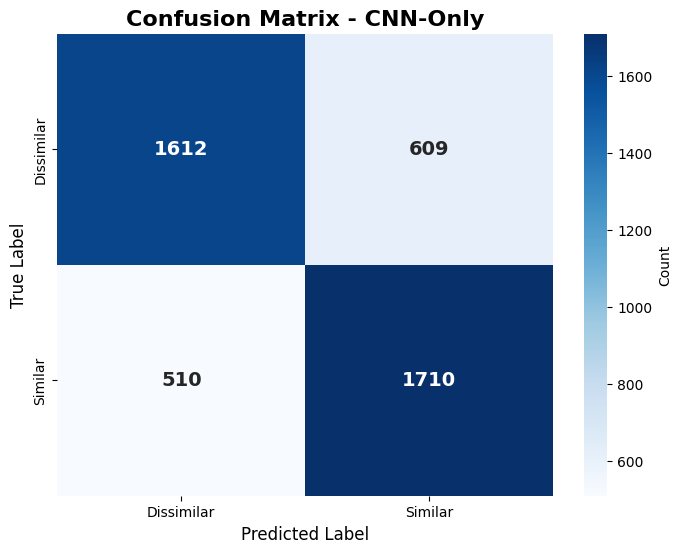

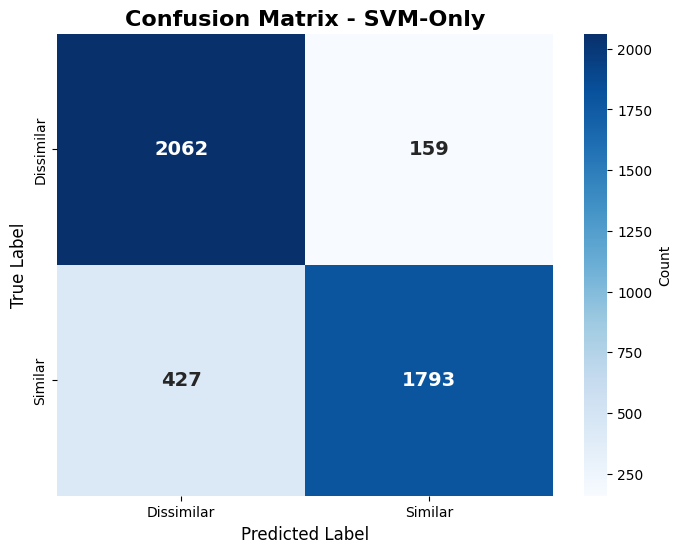

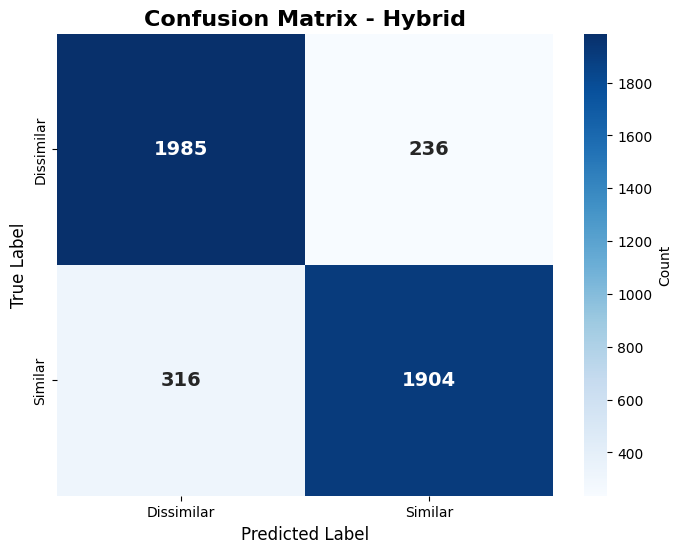

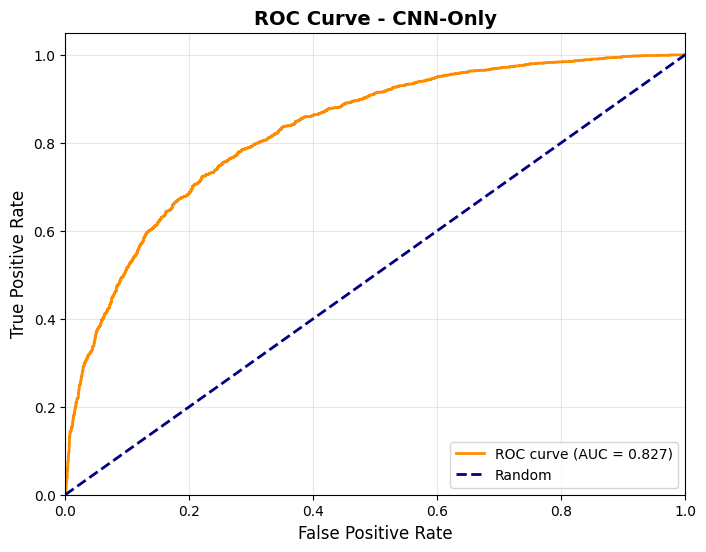

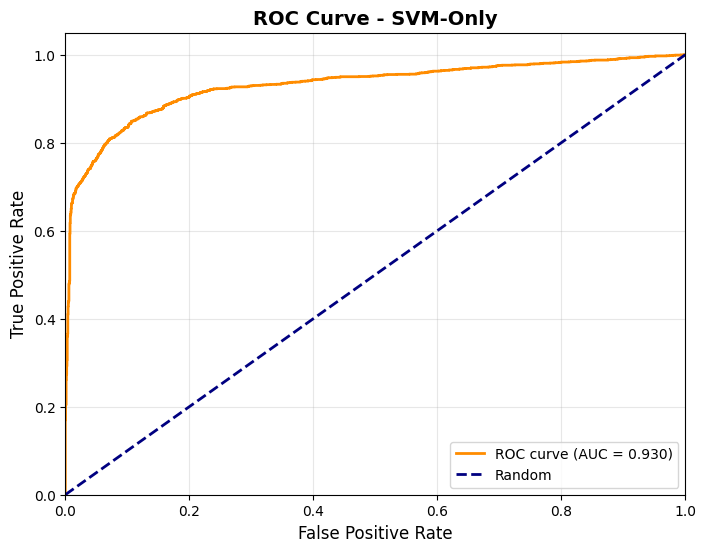

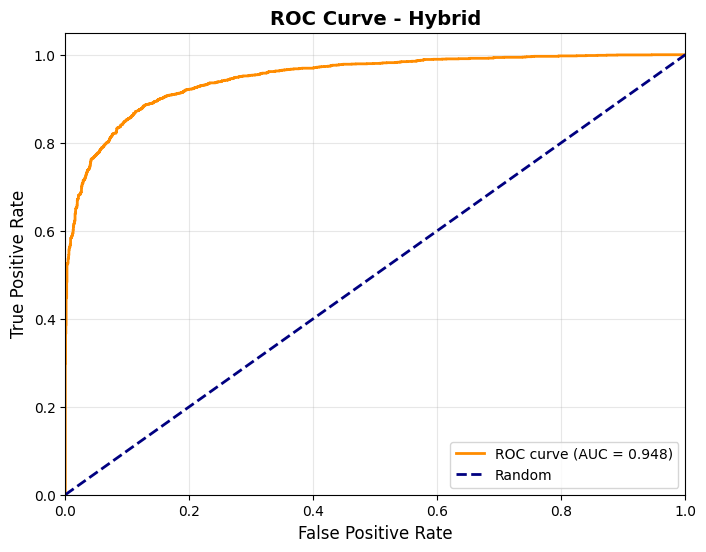


✅ TRAINING & EVALUATION COMPLETE!

📁 Outputs:
   Models:        models/
   Results:       results/
   Visualizations: results/

🎯 Summary:
   CNN-Only F1:   0.7535
   SVM-Only F1:   0.8595
   Hybrid F1:     0.8734


In [1]:
# STEP 2 & 3: CNN+SVM ARCHITECTURE WITH ADVANCED FEATURE ENGINEERING
# =============================================================================
# This notebook builds CNN-only, SVM-only, and hybrid CNN+SVM models
# for trademark similarity detection with comprehensive metrics comparison
# Input: Processed CSV from Step 1
# Output: Trained models + evaluation metrics + comparison
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import pickle
import json
from pathlib import Path
from datetime import datetime

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers, metrics
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Machine Learning
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
    average_precision_score, log_loss
)

# Feature Engineering (from Step 1)
import jellyfish
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 80)
print("STEP 2 & 3: CNN-ONLY, SVM-ONLY & HYBRID COMPARISON")
print("=" * 80)

# =============================================================================
# CONFIGURATION
# =============================================================================

class ModelConfig:
    """Configuration for model training"""
    def __init__(self):
        # Data - Load from pipeline config
        try:
            with open('pipeline_config.json', 'r') as f:
                pipeline_cfg = json.load(f)
            self.DATA_FILE = pipeline_cfg['processed_data_file']
            print(f"✅ Using dataset from Step 1: {self.DATA_FILE}")
        except FileNotFoundError:
            raise FileNotFoundError("Run Step 1 first to generate the processed dataset!")
        
        # Split sizes
        self.TEST_SIZE = 0.15
        self.VAL_SIZE = 0.15
        
        # CNN Architecture
        self.MAX_SEQUENCE_LENGTH = 50
        self.MAX_VOCAB_SIZE = 10000
        self.EMBEDDING_DIM = 128
        self.CNN_FILTERS = [128, 64, 32]
        self.CNN_KERNEL_SIZES = [3, 4, 5]
        self.DROPOUT_RATE = 0.5
        
        # Training
        self.BATCH_SIZE = 32
        self.EPOCHS = 50
        self.LEARNING_RATE = 0.001
        self.EARLY_STOPPING_PATIENCE = 10
        
        # SVM
        self.SVM_KERNEL = 'rbf'
        self.SVM_C = 1.0
        self.SVM_GAMMA = 'scale'
        
        # Output directories
        self.MODEL_DIR = Path('models')
        self.RESULTS_DIR = Path('results')
        
        # Create directories
        self.MODEL_DIR.mkdir(exist_ok=True)
        self.RESULTS_DIR.mkdir(exist_ok=True)

# Initialize config
config = ModelConfig()

# =============================================================================
# DATA LOADER
# =============================================================================

class TrademarkDataLoader:
    """Load and prepare trademark data"""
    
    def __init__(self, file_path: str):
        self.df = pd.read_csv(file_path)
        print(f"✓ Loaded {len(self.df)} trademark pairs")
        print(f"  Positive: {(self.df['label']==1).sum()}")
        print(f"  Negative: {(self.df['label']==0).sum()}")
    
    def get_text_pairs(self) -> Tuple[List[str], List[str]]:
        """Get wordmark pairs as text lists"""
        mark1 = self.df['mark1_wordmark'].fillna('').tolist()
        mark2 = self.df['mark2_wordmark'].fillna('').tolist()
        return mark1, mark2
    
    def get_labels(self) -> np.ndarray:
        """Get similarity labels"""
        return self.df['label'].values
    
    def get_linguistic_features(self) -> np.ndarray:
        """Extract all pre-computed linguistic features from Step 1"""
        feature_cols = [
            'visual_levenshtein', 'visual_jaro_winkler',
            'soundex_match', 'metaphone_match',
            'semantic_similarity_en', 'semantic_similarity_ha', 'semantic_similarity_yo',
            'length_diff', 'mark1_length', 'mark2_length'
        ]
        
        features = self.df[feature_cols].fillna(0).values
        print(f"✓ Extracted {features.shape[1]} linguistic features")
        return features
    
    def split_data(self, test_size=0.15, val_size=0.15, random_state=42):
        """Stratified train/val/test split"""
        mark1, mark2 = self.get_text_pairs()
        labels = self.get_labels()
        features = self.get_linguistic_features()
        
        # First split: train+val vs test
        train_val_size = 1.0 - test_size
        X_train_val_m1, X_test_m1, X_train_val_m2, X_test_m2, \
        y_train_val, y_test, features_train_val, features_test = train_test_split(
            mark1, mark2, labels, features,
            test_size=test_size,
            stratify=labels,
            random_state=random_state
        )
        
        # Second split: train vs val
        val_size_adjusted = val_size / train_val_size
        X_train_m1, X_val_m1, X_train_m2, X_val_m2, \
        y_train, y_val, features_train, features_val = train_test_split(
            X_train_val_m1, X_train_val_m2, y_train_val, features_train_val,
            test_size=val_size_adjusted,
            stratify=y_train_val,
            random_state=random_state
        )
        
        print(f"\n📊 Data Split:")
        print(f"   Train: {len(y_train)} ({(y_train==1).sum()} positive)")
        print(f"   Val:   {len(y_val)} ({(y_val==1).sum()} positive)")
        print(f"   Test:  {len(y_test)} ({(y_test==1).sum()} positive)")
        
        return {
            'train': (X_train_m1, X_train_m2, y_train, features_train),
            'val': (X_val_m1, X_val_m2, y_val, features_val),
            'test': (X_test_m1, X_test_m2, y_test, features_test)
        }

# =============================================================================
# CHARACTER-LEVEL CNN ENCODER
# =============================================================================

class CharacterCNNEncoder:
    """Character-level CNN for trademark text encoding"""
    
    def __init__(self, config: ModelConfig):
        self.config = config
        self.tokenizer = None
        self.model = None
        self.encoder = None
        self.history = None
    
    def build_tokenizer(self, texts: List[str]):
        """Build character-level tokenizer"""
        self.tokenizer = Tokenizer(
            num_words=self.config.MAX_VOCAB_SIZE,
            char_level=True,
            oov_token='<UNK>'
        )
        self.tokenizer.fit_on_texts(texts)
        print(f"✓ Built character tokenizer (vocab size: {len(self.tokenizer.word_index)})")
    
    def encode_texts(self, texts: List[str]) -> np.ndarray:
        """Convert texts to padded sequences"""
        sequences = self.tokenizer.texts_to_sequences(texts)
        padded = pad_sequences(
            sequences,
            maxlen=self.config.MAX_SEQUENCE_LENGTH,
            padding='post',
            truncating='post'
        )
        return padded
    
    def build_siamese_cnn(self):
        """Build Siamese CNN architecture for pair comparison"""
        # Shared character encoder
        char_input = layers.Input(shape=(self.config.MAX_SEQUENCE_LENGTH,), name='char_input')
        
        # Embedding layer
        x = layers.Embedding(
            input_dim=len(self.tokenizer.word_index) + 1,
            output_dim=self.config.EMBEDDING_DIM,
            input_length=self.config.MAX_SEQUENCE_LENGTH,
            name='embedding'
        )(char_input)
        
        # Multiple parallel CNN branches (different kernel sizes)
        conv_outputs = []
        for i, (filters, kernel_size) in enumerate(
            zip(self.config.CNN_FILTERS, self.config.CNN_KERNEL_SIZES)
        ):
            conv = layers.Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                activation='relu',
                name=f'conv_{kernel_size}'
            )(x)
            pool = layers.GlobalMaxPooling1D(name=f'pool_{kernel_size}')(conv)
            conv_outputs.append(pool)
        
        # Concatenate all CNN outputs
        concatenated = layers.Concatenate(name='concat_cnn')(conv_outputs)
        
        # Dense layers
        dense = layers.Dense(256, activation='relu', name='dense_1')(concatenated)
        dense = layers.Dropout(self.config.DROPOUT_RATE, name='dropout_1')(dense)
        dense = layers.Dense(128, activation='relu', name='dense_2')(dense)
        dense = layers.Dropout(self.config.DROPOUT_RATE, name='dropout_2')(dense)
        embedding_output = layers.Dense(64, activation='relu', name='embedding_output')(dense)
        
        # Build shared encoder
        self.encoder = models.Model(inputs=char_input, outputs=embedding_output, name='cnn_encoder')
        
        # Siamese architecture
        input_mark1 = layers.Input(shape=(self.config.MAX_SEQUENCE_LENGTH,), name='mark1')
        input_mark2 = layers.Input(shape=(self.config.MAX_SEQUENCE_LENGTH,), name='mark2')
        
        # Get embeddings for both marks using shared encoder
        embedding_mark1 = self.encoder(input_mark1)
        embedding_mark2 = self.encoder(input_mark2)
        
        # Compute similarity features
        # 1. Absolute difference
        diff = layers.Lambda(lambda x: tf.abs(x[0] - x[1]))([embedding_mark1, embedding_mark2])
        
        # 2. Element-wise product
        product = layers.Multiply()([embedding_mark1, embedding_mark2])
        
        # 3. Concatenate all
        merged = layers.Concatenate()([embedding_mark1, embedding_mark2, diff, product])
        
        # Classification head
        x = layers.Dense(128, activation='relu', name='classifier_dense_1')(merged)
        x = layers.Dropout(self.config.DROPOUT_RATE, name='classifier_dropout')(x)
        x = layers.Dense(64, activation='relu', name='classifier_dense_2')(x)
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        
        # Build full model
        self.model = models.Model(
            inputs=[input_mark1, input_mark2],
            outputs=output,
            name='siamese_cnn'
        )
        
        # Compile
        self.model.compile(
            optimizer=optimizers.Adam(learning_rate=self.config.LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy', metrics.Precision(), metrics.Recall()]
        )
        
        print("\n🏗️  CNN Architecture:")
        self.model.summary()
        
        return self.model
    
    def train(self, train_data, val_data, epochs=50):
        """Train the Siamese CNN"""
        X_train_m1, X_train_m2, y_train = train_data
        X_val_m1, X_val_m2, y_val = val_data
        
        # Callbacks
        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=self.config.EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        )
        
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
        
        checkpoint = callbacks.ModelCheckpoint(
            str(config.MODEL_DIR / 'best_cnn_model.h5'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
        
        # Train
        print("\n🚀 Training CNN...")
        self.history = self.model.fit(
            [X_train_m1, X_train_m2], y_train,
            validation_data=([X_val_m1, X_val_m2], y_val),
            epochs=epochs,
            batch_size=self.config.BATCH_SIZE,
            callbacks=[early_stop, reduce_lr, checkpoint],
            verbose=1
        )
        
        return self.history
    
    def predict_proba(self, mark1_seq: np.ndarray, mark2_seq: np.ndarray) -> np.ndarray:
        """Predict similarity probabilities using CNN"""
        return self.model.predict([mark1_seq, mark2_seq], verbose=0).flatten()
    
    def predict(self, mark1_seq: np.ndarray, mark2_seq: np.ndarray, threshold=0.5) -> np.ndarray:
        """Predict similarity labels using CNN"""
        proba = self.predict_proba(mark1_seq, mark2_seq)
        return (proba >= threshold).astype(int)
    
    def extract_embeddings(self, texts: List[str]) -> np.ndarray:
        """Extract CNN embeddings for texts"""
        sequences = self.encode_texts(texts)
        embeddings = self.encoder.predict(sequences, verbose=0)
        return embeddings
    
    def save(self, path: str):
        """Save model and tokenizer"""
        model_path = f"{path}.keras"
        self.model.save(model_path)
        with open(f"{path}_tokenizer.pkl", 'wb') as f:
            pickle.dump(self.tokenizer, f)
        print(f"✓ Saved CNN model to {model_path}")

    def load(self, path: str):
        """Load model and tokenizer"""
        model_path = f"{path}.keras"
        self.model = keras.models.load_model(model_path)
        with open(f"{path}_tokenizer.pkl", 'rb') as f:
            self.tokenizer = pickle.load(f)
        # Rebuild encoder
        self.encoder = models.Model(
            inputs=self.model.get_layer('cnn_encoder').input,
            outputs=self.model.get_layer('cnn_encoder').output
        )
        print(f"✓ Loaded CNN model from {model_path}")

# =============================================================================
# SVM-ONLY CLASSIFIER (LINGUISTIC FEATURES ONLY)
# =============================================================================

class SVMOnlyClassifier:
    """SVM using only linguistic features (no CNN)"""
    
    def __init__(self, config: ModelConfig):
        self.config = config
        self.svm = None
        self.scaler = StandardScaler()
    
    def train(self, train_data, val_data=None):
        """Train SVM on linguistic features only"""
        _, _, y_train, features_train = train_data
        
        print("\n🔧 Training SVM with linguistic features only...")
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(features_train)
        
        # Train SVM
        print(f"   Using kernel={self.config.SVM_KERNEL}, C={self.config.SVM_C}")
        self.svm = SVC(
            kernel=self.config.SVM_KERNEL,
            C=self.config.SVM_C,
            gamma=self.config.SVM_GAMMA,
            probability=True,
            random_state=42,
            verbose=True
        )
        self.svm.fit(X_train_scaled, y_train)
        
        # Evaluate on training data
        train_pred = self.svm.predict(X_train_scaled)
        train_acc = accuracy_score(y_train, train_pred)
        print(f"✓ SVM-Only Training Accuracy: {train_acc:.4f}")
        
        # Evaluate on validation if provided
        if val_data is not None:
            _, _, y_val, features_val = val_data
            X_val_scaled = self.scaler.transform(features_val)
            val_pred = self.svm.predict(X_val_scaled)
            val_acc = accuracy_score(y_val, val_pred)
            print(f"✓ SVM-Only Validation Accuracy: {val_acc:.4f}")
    
    def predict(self, linguistic_features: np.ndarray) -> np.ndarray:
        """Predict similarity labels"""
        X_scaled = self.scaler.transform(linguistic_features)
        return self.svm.predict(X_scaled)
    
    def predict_proba(self, linguistic_features: np.ndarray) -> np.ndarray:
        """Predict similarity probabilities"""
        X_scaled = self.scaler.transform(linguistic_features)
        return self.svm.predict_proba(X_scaled)[:, 1]
    
    def save(self, path: str):
        """Save SVM and scaler"""
        with open(path, 'wb') as f:
            pickle.dump({'svm': self.svm, 'scaler': self.scaler}, f)
        print(f"✓ Saved SVM-Only model to {path}")
    
    def load(self, path: str):
        """Load SVM and scaler"""
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.svm = data['svm']
            self.scaler = data['scaler']
        print(f"✓ Loaded SVM-Only model from {path}")

# =============================================================================
# HYBRID CNN+SVM CLASSIFIER
# =============================================================================

class HybridCNNSVM:
    """Combines CNN embeddings with linguistic features for SVM classification"""
    
    def __init__(self, cnn_encoder: CharacterCNNEncoder, config: ModelConfig):
        self.cnn_encoder = cnn_encoder
        self.config = config
        self.svm = None
        self.scaler = StandardScaler()
    
    def extract_hybrid_features(
        self, 
        mark1_texts: List[str], 
        mark2_texts: List[str],
        linguistic_features: np.ndarray
    ) -> np.ndarray:
        """Combine CNN embeddings + linguistic features"""
        # Get CNN embeddings
        emb1 = self.cnn_encoder.extract_embeddings(mark1_texts)
        emb2 = self.cnn_encoder.extract_embeddings(mark2_texts)
        
        # Concatenate: [emb1, emb2, linguistic_features]
        hybrid_features = np.hstack([emb1, emb2, linguistic_features])
        
        print(f"✓ Hybrid features shape: {hybrid_features.shape}")
        return hybrid_features
    
    def train(self, train_data, val_data=None):
        """Train SVM on hybrid features"""
        X_train_m1, X_train_m2, y_train, features_train = train_data
        
        print("\n🔧 Extracting hybrid features for SVM training...")
        X_train_hybrid = self.extract_hybrid_features(
            X_train_m1, X_train_m2, features_train
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train_hybrid)
        
        # Train SVM
        print(f"\n🚀 Training Hybrid SVM (kernel={self.config.SVM_KERNEL})...")
        self.svm = SVC(
            kernel=self.config.SVM_KERNEL,
            C=self.config.SVM_C,
            gamma=self.config.SVM_GAMMA,
            probability=True,
            random_state=42,
            verbose=True
        )
        self.svm.fit(X_train_scaled, y_train)
        
        # Evaluate on training data
        train_pred = self.svm.predict(X_train_scaled)
        train_acc = accuracy_score(y_train, train_pred)
        print(f"✓ Hybrid SVM Training Accuracy: {train_acc:.4f}")
        
        # Evaluate on validation if provided
        if val_data is not None:
            X_val_m1, X_val_m2, y_val, features_val = val_data
            X_val_hybrid = self.extract_hybrid_features(
                X_val_m1, X_val_m2, features_val
            )
            X_val_scaled = self.scaler.transform(X_val_hybrid)
            val_pred = self.svm.predict(X_val_scaled)
            val_acc = accuracy_score(y_val, val_pred)
            print(f"✓ Hybrid SVM Validation Accuracy: {val_acc:.4f}")
    
    def predict(self, mark1_texts: List[str], mark2_texts: List[str], 
                linguistic_features: np.ndarray) -> np.ndarray:
        """Predict similarity labels"""
        X_hybrid = self.extract_hybrid_features(mark1_texts, mark2_texts, linguistic_features)
        X_scaled = self.scaler.transform(X_hybrid)
        return self.svm.predict(X_scaled)
    
    def predict_proba(self, mark1_texts: List[str], mark2_texts: List[str],
                      linguistic_features: np.ndarray) -> np.ndarray:
        """Predict similarity probabilities"""
        X_hybrid = self.extract_hybrid_features(mark1_texts, mark2_texts, linguistic_features)
        X_scaled = self.scaler.transform(X_hybrid)
        return self.svm.predict_proba(X_scaled)[:, 1]
    
    def save(self, path: str):
        """Save SVM and scaler"""
        with open(path, 'wb') as f:
            pickle.dump({'svm': self.svm, 'scaler': self.scaler}, f)
        print(f"✓ Saved Hybrid SVM to {path}")
    
    def load(self, path: str):
        """Load SVM and scaler"""
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.svm = data['svm']
            self.scaler = data['scaler']
        print(f"✓ Loaded Hybrid SVM from {path}")

# =============================================================================
# ENHANCED EVALUATOR WITH COMPREHENSIVE METRICS
# =============================================================================

class ModelEvaluator:
    """Comprehensive model evaluation with multiple metrics"""
    
    @staticmethod
    def calculate_comprehensive_metrics(y_true, y_pred, y_proba) -> Dict:
        """Calculate all relevant metrics for binary classification"""
        
        # Confusion matrix components
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        # Specificity (True Negative Rate)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        # Sensitivity (True Positive Rate / Recall)
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        # False Positive Rate
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        # False Negative Rate
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        
        metrics_dict = {
            # Basic metrics
            'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'specificity': specificity,
            'f1': f1_score(y_true, y_pred, zero_division=0),
            
            # Advanced metrics
            'mcc': matthews_corrcoef(y_true, y_pred),
            'cohen_kappa': cohen_kappa_score(y_true, y_pred),
            'roc_auc': roc_auc_score(y_true, y_proba),
            'avg_precision': average_precision_score(y_true, y_proba),
            'log_loss': log_loss(y_true, y_proba),
            
            # Confusion matrix rates
            'true_positives': int(tp),
            'true_negatives': int(tn),
            'false_positives': int(fp),
            'false_negatives': int(fn),
            'fpr': fpr,
            'fnr': fnr,
            'tpr': sensitivity,
            'tnr': specificity
        }
        
        return metrics_dict
    
    @staticmethod
    def evaluate(y_true, y_pred, y_proba, dataset_name="Test", model_name="Model"):
        """Calculate and display all metrics"""
        metrics_dict = ModelEvaluator.calculate_comprehensive_metrics(y_true, y_pred, y_proba)
        
        print(f"\n{'='*70}")
        print(f"{model_name} - {dataset_name} Set Evaluation")
        print(f"{'='*70}")
        
        print(f"\n📊 Primary Metrics:")
        print(f"   Accuracy:          {metrics_dict['accuracy']:.4f}")
        print(f"   Balanced Accuracy: {metrics_dict['balanced_accuracy']:.4f}")
        print(f"   Precision:         {metrics_dict['precision']:.4f}")
        print(f"   Recall (TPR):      {metrics_dict['recall']:.4f}")
        print(f"   Specificity (TNR): {metrics_dict['specificity']:.4f}")
        print(f"   F1 Score:          {metrics_dict['f1']:.4f}")
        
        print(f"\n🎯 Advanced Metrics:")
        print(f"   ROC-AUC:           {metrics_dict['roc_auc']:.4f}")
        print(f"   Avg Precision:     {metrics_dict['avg_precision']:.4f}")
        print(f"   Matthews Corr:     {metrics_dict['mcc']:.4f}")
        print(f"   Cohen's Kappa:     {metrics_dict['cohen_kappa']:.4f}")
        print(f"   Log Loss:          {metrics_dict['log_loss']:.4f}")
        
        print(f"\n📈 Error Rates:")
        print(f"   False Positive Rate: {metrics_dict['fpr']:.4f}")
        print(f"   False Negative Rate: {metrics_dict['fnr']:.4f}")
        
        print(f"\n🔢 Confusion Matrix:")
        print(f"   True Positives:  {metrics_dict['true_positives']}")
        print(f"   True Negatives:  {metrics_dict['true_negatives']}")
        print(f"   False Positives: {metrics_dict['false_positives']}")
        print(f"   False Negatives: {metrics_dict['false_negatives']}")
        
        # Classification report
        print(f"\n{classification_report(y_true, y_pred, target_names=['Dissimilar', 'Similar'])}")
        
        return metrics_dict
    
    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", save_path=None):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Dissimilar', 'Similar'],
                   yticklabels=['Dissimilar', 'Similar'],
                   cbar_kws={'label': 'Count'},
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'})
        plt.ylabel('True Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.title(title, fontsize=16, fontweight='bold')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    @staticmethod
    def plot_roc_curve(y_true, y_proba, title="ROC Curve", save_path=None):
        """Plot ROC curve"""
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title(title, fontsize=14, fontweight='bold')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    @staticmethod
    def plot_training_history(history, save_path=None):
        """Plot CNN training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Loss
        ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
        ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.set_title('Training & Validation Loss', fontweight='bold', fontsize=14)
        ax1.legend(fontsize=11)
        ax1.grid(alpha=0.3)
        
        # Accuracy
        ax2.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
        ax2.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
        ax2.set_xlabel('Epoch', fontsize=12)
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.set_title('Training & Validation Accuracy', fontweight='bold', fontsize=14)
        ax2.legend(fontsize=11)
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    @staticmethod
    def compare_models(metrics_dict_list: List[Dict], model_names: List[str], save_path=None):
        """Compare multiple models across all metrics"""
        
        # Select key metrics for comparison
        key_metrics = [
            'accuracy', 'balanced_accuracy', 'precision', 'recall', 
            'specificity', 'f1', 'roc_auc', 'mcc', 'cohen_kappa'
        ]
        
        # Create comparison dataframe
        comparison_df = pd.DataFrame([
            {metric: metrics[metric] for metric in key_metrics}
            for metrics in metrics_dict_list
        ], index=model_names)
        
        # Plot comparison
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        axes = axes.flatten()
        
        colors = ['#3498db', '#e74c3c', '#2ecc71']
        
        for idx, metric in enumerate(key_metrics):
            ax = axes[idx]
            values = comparison_df[metric].values
            bars = ax.bar(model_names, values, color=colors[:len(model_names)], 
                         alpha=0.7, edgecolor='black', linewidth=1.5)
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}', ha='center', va='bottom', 
                       fontsize=11, fontweight='bold')
            
            ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
            ax.set_title(f'{metric.replace("_", " ").title()} Comparison', 
                        fontsize=14, fontweight='bold')
            ax.set_ylim([0, 1.0])
            ax.grid(axis='y', alpha=0.3)
            ax.set_xticklabels(model_names, rotation=15, ha='right')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print comparison table
        print("\n" + "="*90)
        print("MODEL COMPARISON TABLE")
        print("="*90)
        print(comparison_df.to_string())
        print("="*90)
        
        # Highlight best model for each metric
        print("\n🏆 Best Model per Metric:")
        for metric in key_metrics:
            best_model = comparison_df[metric].idxmax()
            best_value = comparison_df[metric].max()
            print(f"   {metric.replace('_', ' ').title():20s}: {best_model:15s} ({best_value:.4f})")
        
        return comparison_df

# =============================================================================
# MAIN TRAINING PIPELINE
# =============================================================================

def main():
    """Run complete training pipeline with all three models"""
    
    print("\n" + "="*80)
    print("COMPREHENSIVE MODEL TRAINING & COMPARISON")
    print("="*80)
    
    # 1. Load Data
    print("\n📂 Loading preprocessed data...")
    loader = TrademarkDataLoader(config.DATA_FILE)
    data_splits = loader.split_data(
        test_size=config.TEST_SIZE,
        val_size=config.VAL_SIZE
    )
    
    # =========================================================================
    # STEP 1: TRAIN CNN-ONLY MODEL
    # =========================================================================
    print("\n" + "="*80)
    print("MODEL 1: CNN-ONLY (Siamese Network)")
    print("="*80)
    
    cnn = CharacterCNNEncoder(config)
    
    # Build tokenizer on all training text
    all_train_texts = data_splits['train'][0] + data_splits['train'][1]
    cnn.build_tokenizer(all_train_texts)
    
    # Encode all datasets
    print("\n🔤 Encoding texts to sequences...")
    train_m1_seq = cnn.encode_texts(data_splits['train'][0])
    train_m2_seq = cnn.encode_texts(data_splits['train'][1])
    val_m1_seq = cnn.encode_texts(data_splits['val'][0])
    val_m2_seq = cnn.encode_texts(data_splits['val'][1])
    test_m1_seq = cnn.encode_texts(data_splits['test'][0])
    test_m2_seq = cnn.encode_texts(data_splits['test'][1])
    
    # Build and train CNN
    cnn.build_siamese_cnn()
    history = cnn.train(
        train_data=(train_m1_seq, train_m2_seq, data_splits['train'][2]),
        val_data=(val_m1_seq, val_m2_seq, data_splits['val'][2]),
        epochs=config.EPOCHS
    )
    
    # Plot training history
    ModelEvaluator.plot_training_history(
        history,
        save_path=config.RESULTS_DIR / 'cnn_training_history.png'
    )
    
    # Evaluate CNN-only on test set
    print("\n📊 Evaluating CNN-Only Model...")
    y_test = data_splits['test'][2]
    cnn_pred = cnn.predict(test_m1_seq, test_m2_seq)
    cnn_proba = cnn.predict_proba(test_m1_seq, test_m2_seq)
    
    cnn_metrics = ModelEvaluator.evaluate(
        y_test, cnn_pred, cnn_proba, 
        dataset_name="Test", model_name="CNN-Only"
    )
    
    # Save CNN
    cnn.save(str(config.MODEL_DIR / 'cnn_encoder'))
    
    # =========================================================================
    # STEP 2: TRAIN SVM-ONLY MODEL
    # =========================================================================
    print("\n" + "="*80)
    print("MODEL 2: SVM-ONLY (Linguistic Features)")
    print("="*80)
    
    svm_only = SVMOnlyClassifier(config)
    svm_only.train(
        train_data=data_splits['train'],
        val_data=data_splits['val']
    )
    
    # Evaluate SVM-only on test set
    print("\n📊 Evaluating SVM-Only Model...")
    _, _, y_test, features_test = data_splits['test']
    svm_pred = svm_only.predict(features_test)
    svm_proba = svm_only.predict_proba(features_test)
    
    svm_metrics = ModelEvaluator.evaluate(
        y_test, svm_pred, svm_proba,
        dataset_name="Test", model_name="SVM-Only"
    )
    
    # Save SVM
    svm_only.save(str(config.MODEL_DIR / 'svm_only.pkl'))
    
    # =========================================================================
    # STEP 3: TRAIN HYBRID CNN+SVM MODEL
    # =========================================================================
    print("\n" + "="*80)
    print("MODEL 3: HYBRID CNN+SVM")
    print("="*80)
    
    hybrid_model = HybridCNNSVM(cnn, config)
    hybrid_model.train(
        train_data=data_splits['train'],
        val_data=data_splits['val']
    )
    
    # Evaluate Hybrid on test set
    print("\n📊 Evaluating Hybrid CNN+SVM Model...")
    X_test_m1, X_test_m2, y_test, features_test = data_splits['test']
    hybrid_pred = hybrid_model.predict(X_test_m1, X_test_m2, features_test)
    hybrid_proba = hybrid_model.predict_proba(X_test_m1, X_test_m2, features_test)
    
    hybrid_metrics = ModelEvaluator.evaluate(
        y_test, hybrid_pred, hybrid_proba,
        dataset_name="Test", model_name="Hybrid CNN+SVM"
    )
    
    # Save Hybrid
    hybrid_model.save(str(config.MODEL_DIR / 'hybrid_svm.pkl'))
    
    # =========================================================================
    # STEP 4: COMPREHENSIVE COMPARISON
    # =========================================================================
    print("\n" + "="*80)
    print("MODEL COMPARISON & ANALYSIS")
    print("="*80)
    
    # Compare all models
    comparison_df = ModelEvaluator.compare_models(
        metrics_dict_list=[cnn_metrics, svm_metrics, hybrid_metrics],
        model_names=['CNN-Only', 'SVM-Only', 'Hybrid'],
        save_path=config.RESULTS_DIR / 'model_comparison.png'
    )
    
    # Plot individual confusion matrices
    ModelEvaluator.plot_confusion_matrix(
        y_test, cnn_pred, 
        title="Confusion Matrix - CNN-Only",
        save_path=config.RESULTS_DIR / 'confusion_matrix_cnn.png'
    )
    
    ModelEvaluator.plot_confusion_matrix(
        y_test, svm_pred,
        title="Confusion Matrix - SVM-Only",
        save_path=config.RESULTS_DIR / 'confusion_matrix_svm.png'
    )
    
    ModelEvaluator.plot_confusion_matrix(
        y_test, hybrid_pred,
        title="Confusion Matrix - Hybrid",
        save_path=config.RESULTS_DIR / 'confusion_matrix_hybrid.png'
    )
    
    # Plot ROC curves
    ModelEvaluator.plot_roc_curve(
        y_test, cnn_proba,
        title="ROC Curve - CNN-Only",
        save_path=config.RESULTS_DIR / 'roc_curve_cnn.png'
    )
    
    ModelEvaluator.plot_roc_curve(
        y_test, svm_proba,
        title="ROC Curve - SVM-Only",
        save_path=config.RESULTS_DIR / 'roc_curve_svm.png'
    )
    
    ModelEvaluator.plot_roc_curve(
        y_test, hybrid_proba,
        title="ROC Curve - Hybrid",
        save_path=config.RESULTS_DIR / 'roc_curve_hybrid.png'
    )
    
    # =========================================================================
    # STEP 5: SAVE COMPREHENSIVE RESULTS
    # =========================================================================
    results = {
        'models': {
            'cnn_only': cnn_metrics,
            'svm_only': svm_metrics,
            'hybrid': hybrid_metrics
        },
        'comparison': comparison_df.to_dict(),
        'data_splits': {
            'train_size': len(data_splits['train'][2]),
            'val_size': len(data_splits['val'][2]),
            'test_size': len(data_splits['test'][2])
        },
        'configuration': {
            'cnn_filters': config.CNN_FILTERS,
            'cnn_kernel_sizes': config.CNN_KERNEL_SIZES,
            'svm_kernel': config.SVM_KERNEL,
            'svm_C': config.SVM_C,
            'epochs': config.EPOCHS,
            'batch_size': config.BATCH_SIZE
        },
        'timestamp': datetime.now().isoformat()
    }
    
    with open(config.RESULTS_DIR / 'evaluation_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print("\n" + "="*80)
    print("✅ TRAINING & EVALUATION COMPLETE!")
    print("="*80)
    print(f"\n📁 Outputs:")
    print(f"   Models:        {config.MODEL_DIR}/")
    print(f"   Results:       {config.RESULTS_DIR}/")
    print(f"   Visualizations: {config.RESULTS_DIR}/")
    
    print("\n🎯 Summary:")
    print(f"   CNN-Only F1:   {cnn_metrics['f1']:.4f}")
    print(f"   SVM-Only F1:   {svm_metrics['f1']:.4f}")
    print(f"   Hybrid F1:     {hybrid_metrics['f1']:.4f}")
    
    return {
        'cnn': cnn,
        'svm_only': svm_only,
        'hybrid': hybrid_model,
        'metrics': results
    }

# Run training
if __name__ == "__main__":
    models = main()
